# White Noise Drive Qubit Excitation Spectrum

**Author: Daniel Gonçalves Benvenutti – UNICAMP**
15 August 2025

Qutip Version: 5.2.0

---

## Theory

### The Cauchy Distribution

A Cauchy distribution is described by a Lorentzian curve:

$P(f) = \frac{A\gamma^2}{f^2+\gamma^2} = \frac{A}{(f/\gamma)^2+1}.$

The main property of this distribution is that it does not follow the law of large numbers. Consequently, measurements sampled from it do not converge to a normal distribution. A PSD (power spectral density) of quantum measurements that follow a Lorentzian form will therefore remain Lorentzian and conserve the original PSD, unlike in the case of a random walk (Brownian noise), where averaging attenuates the amplitude and sampling converges to white noise.

The PSD of the random fluctuations of a qubit’s excitation probability under white noise also takes a Lorentzian form. Thus, averaging and sampling smooth out the non-Lorentzian features, leaving a Lorentzian curve centered at zero. This PSD resembles that of a random walk, although the PSD and the time evolution differ in the ways explained above.


## Methods

The simulations were performed on two-level systems with white noise as a time-dependent term in the Hamiltonian. The resulting drift was converted to a spectrum using the Welch method from the *scipy* library. By adjusting the segment size in Welch’s method, it was possible to trade resolution for smoothness of the PSD, either averaging over the full dataset for smoother results or using shorter segments for higher resolution. The resulting zero-centered Lorentzian was then fitted to extract the curve parameters.

The main parameters of these simulations were $T_1$, $T_2$, and the white noise amplitude. The way the white noise was generated made the number of interpolation points relevant: fewer points broadened the effective PSD (which was not normalized), concentrating more energy near the qubit resonance, while more points narrowed it.

Several analyses were performed on the resulting data, both on the PSD and its Lorentzian fit, and on the raw time-domain expectation values. A key observable was the volatility of the longitudinal expectation value ($\sigma_z$).


## Results

A relationship was found between the number of interpolation points, the white noise amplitude, and $T_1$. This relationship defines a regime change in which the drift drives the qubit into saturation, leaving it in a superposition state with $\langle \sigma\_z \rangle \approx 0$. A smaller $T_1$ requires a larger noise amplitude to reach saturation. Using fewer interpolation points for the noise also lowers the amplitude threshold for saturation.

This regime change also appears in the spectrum: the Lorentzian PSD peak amplitude stops increasing with noise amplitude once saturation occurs. Meanwhile, the volatility of the drift (measured over the entire dataset) increases more robustly with noise amplitude, following an approximately linear scaling in a log-log plot.

Plotting the PSD on a log-log scale reveals a slope of about –1.854, very close to the –2 slope characteristic of Brownian motion, which explains the strong resemblance to a random walk.

Scanning $T_1$, we observe its role only in the drift saturation and regime change. No clear dependence of Lorentzian fit parameters on $T_1$ was found, aside from peak amplitude at strong damping. The same applies to $T_2$, which also showed no apparent influence on the drift regime transition.



## Analysis

The spectrum of qubit drift under white noise contains rich information about both the qubit and the noise. For instance, shifting the qubit resonance frequency could enable probing the PSD of the noise affecting its drive, since noise near resonance strongly impacts the volatility and the drift's PSD Lorenztian amplitude.

A qubit with a short $T_1$ could be advantageous to prevent saturation, expanding the accessible range of noise amplitudes for study. Finally, while this simulation revealed no straightforward relationship between drift PSD features and intrinsic decoherence parameters such as $T_1$ and $T_2$, this does not rule out the possibility that more advanced techniques could extract such information from qubit dynamics.



In [3]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 62.1 MB/s eta 0:00:00


In [3]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import welch
from tqdm import tqdm
#from tqdm.notebook import tqdm

## Simulation Parameters



In [ ]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
      # (T2 must be T2<=2T1)
  elif T2>2*T1:
    raise Exception("T2 must be T2<=2T1")
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms

def simulation(Ed,T1, T2, e="xyz"):
  lenght=20_000 #ns
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2e}ns")
  # expected value operators desired (present in sting "e")
  e_ops=[]
  if "x" in e:
    e_ops.append(sx)
  if "y" in e:
    e_ops.append(sy)
  if "z" in e:
    e_ops.append(sz)

  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*6*wq/2/np.pi))
  drive_data=Ed*np.random.normal(0,1, tlist.shape) #10% Ed amplitude

  #simulation steps
  t=np.linspace(0,lenght,int(lenght*2.1*wq/2/np.pi)) #ns

  # initial state
  psi0=qtp.basis(2,0)
  options=dict(nsteps=None, atol=5e-7, rtol=5e-5,)
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops=c_ops(T1,T2),e_ops=e_ops,options=options)
  return t, res


# Plots

In [ ]:
def plot_fft_tomography(t, expect, graphs="xyz", nperseg=256):
  # plots a graph with the fft with the welch PSD method of all selected directions of Pauli matrices (x, y, z)
  # nperseg is the segment size for the welch method, a bigger nperseg means bigger segments with less averages
  #  and more resolution in the frequency domain
  
  # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))  # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  dt=t[1]-t[0]
  

  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(*welch(expect[graphs.index("x")], fs=1/dt, nperseg=nperseg))
    axes[graphs.index("x")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title('Tomography of the noisy oscillation \n Expectation Value of $\\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(*welch(expect[graphs.index("y")], fs=1/dt, nperseg=nperseg))
    axes[graphs.index("y")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title('Expectation Value of $\\sigma_y$')

  # Plot sz
  if "z" in graphs:
    w=welch(expect[graphs.index("z")],fs=1/dt, nperseg=nperseg)
    DC=w[1][0]
    w = [v[1:] for v in w]
    axes[graphs.index("z")].plot(*w)
    axes[graphs.index("z")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title('Expectation Value of $\\sigma_z$')
    print(f"DC: {DC}")


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def plot_tomography(t, expect, graphs="xyz"):
  # plots a graph of the time evolution of all selected directions of Pauli matrices (x, y, z)
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))   # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(t, expect[graphs.index("x")])
    axes[graphs.index("x")].set_xlabel('Time (ns)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title(r'Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(t, expect[graphs.index("y")])
    axes[graphs.index("y")].set_xlabel('Time (ns)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title(r'Expectation Value of $\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(t, expect[graphs.index("z")])
    axes[graphs.index("z")].set_xlabel('Time (ns)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title(r'Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def diffusive_scale(dt, signal):
    """
    Returns the slope of variance vs lag in log-log scale
    For pure Brownian motion, slope ≈ 1
    """
    n = len(signal)
    lags = np.arange(1, n//2)
    variances = [np.var(signal[lag:] - signal[:-lag]) for lag in lags]
    slope, _ = np.polyfit(np.log(dt*lags), np.log(variances), 1)
    #diffusive scale
    D=slope
    return D

def lorenztian_fit(t, sigz, T, split =100, nperseg=256):
  # zooms in and fits the sigz data vetor with a lorentzian centered at 0
  # split is the amount of zoom
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  #freq = np.fft.rfftfreq(len(t), d=dt)

  start=1 # remove DC
  split=split
  # FFT of sigz betweeen start and split
  #X=np.abs(np.fft.rfft(sigz))[start:split]
  #freq_subset = freq[start:split]
  
  freq,X =welch(sigz, fs=1/dt, nperseg=nperseg)
  freq_subset=freq[start:split]
  X=X[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset

  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[X[0],1/T/2/np.pi, X[-1]])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  plt.plot(freq_subset, X_fit, label='Fit', color='red')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(r'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()

  print(f"Fitted gamma: {gamma_fit:.2e}")
  print(f"Fitted 1/gamma: {1/gamma_fit:.2e}")
  print(f"Fitted gamma*2pi: {gamma_fit*2*np.pi:.2e}")
  print(f"Fitted 1/gamma/2pi: {1/gamma_fit/2/np.pi:.2e}")
  print(f"Fitted Offset: {offset_fit:.2e}")
  print(f"Fitted Amplitude : {A_fit:.2e}")
  # calculates volatility, the variance of the increments in time (returns in stock market volatility)
  print(f"var of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")
  
def autocorr(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size // 2:]
def plot_auto(t, X):
  plt.plot(t, autocorr(X), color='blue')
  plt.xlabel('lag (ns)')
  plt.ylabel('Autocorrelation')
  plt.title(r'Autocorrelation of qubit drift')
  plt.legend()
  plt.show()



# Average conserves random walk like property
This does simple averages of several drift curves from a qubit under white noise drive compared to a drift with no averages

In [ ]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

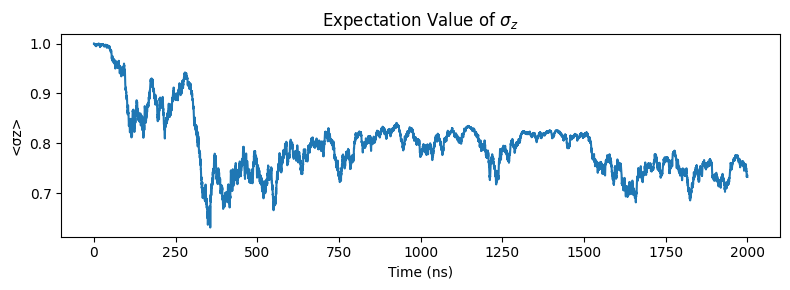

In [26]:
plot_tomography(t, res.expect, graphs="z")

In [ ]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=10
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

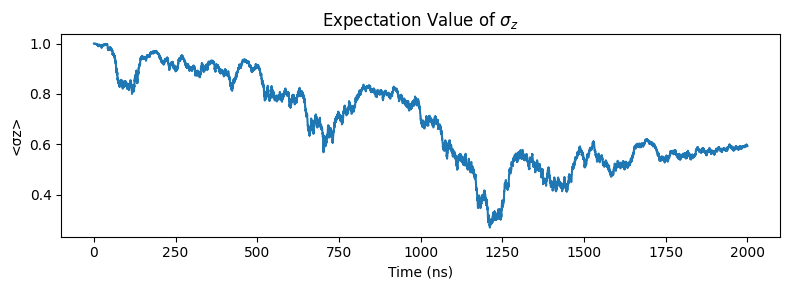

In [28]:
plot_tomography(t, res.expect, graphs="z")

# Brownian like motion
Does fits of the log-log curve of the PSD. A straight line with slope -2 is brownian motion/noise

In [ ]:
T1=10000 #relaxation time [ns]
T2=20000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:11<00:00, 71.31s/it]


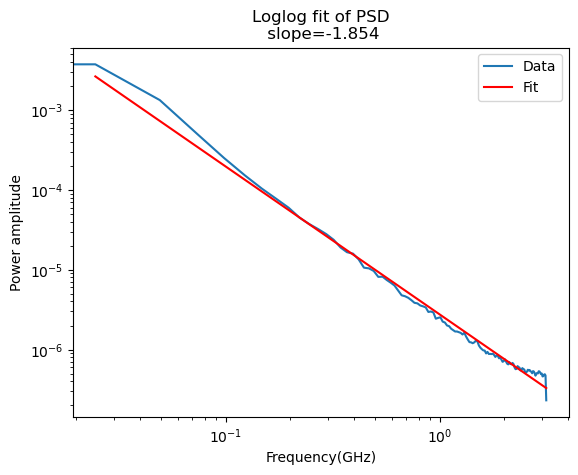

In [ ]:
w=welch(res.expect[2],fs=1/(t[1]-t[0]))
plt.loglog(*w, label="Data")

poly = np.poly1d(np.polyfit(np.log(w[0][1:]), np.log(w[1][1:]),deg=1))
fit=np.exp(poly(np.log(w[0][1:])))
plt.loglog(w[0][1:],fit, color="red", label="Fit")
plt.title(f"Loglog fit of PSD\n slope={poly[1]:.3f}")
plt.ylabel("Power amplitude")
plt.xlabel("Frequency(GHz)")
plt.legend()
plt.show()

In [22]:
T1=10 #relaxation time [ns]
T2=10 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:39<00:00, 99.68s/it]


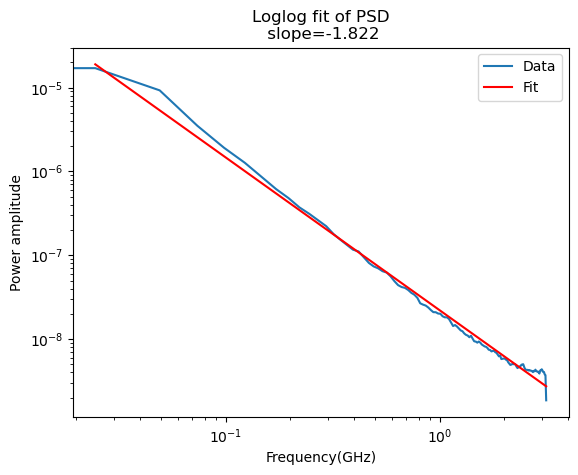

In [39]:
w=welch(res.expect[2],fs=1/(t[1]-t[0]))
plt.loglog(*w, label="Data")

poly = np.poly1d(np.polyfit(np.log10(w[0][1:]), np.log10(w[1][1:]),deg=1))
fit=10**(poly(np.log10(w[0][1:])))
plt.loglog(w[0][1:],fit, color="red", label="Fit")
plt.title(f"Loglog fit of PSD\n slope={poly[1]:.3f}")
plt.ylabel("Power amplitude")
plt.xlabel("Frequency(GHz)")
plt.legend()
plt.show()

# Scan Ed $T_1=10\mu s , T_2= 200ns$
Scans several white noise amplitudes `Ed` with the tile parameters fixed

In [62]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.004*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:05<00:00, 65.76s/it]


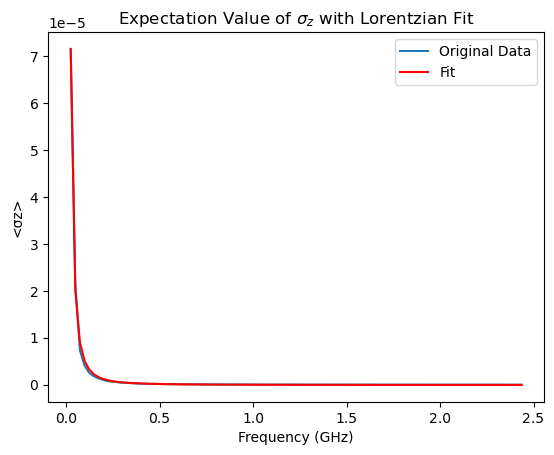

Fitted gamma: 1.01e-02
Fitted 1/gamma: 9.90e+01
Fitted gamma*2pi: 6.35e-02
Fitted 1/gamma/2pi: 1.58e+01
Fitted Offset: -5.35e-08
Fitted Amplitude : 4.96e-04
var of increments (volatility): 9.532168070221488e-08


In [66]:
lorenztian_fit(t, avgz, T2,)

In [71]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:12<00:00, 72.42s/it]


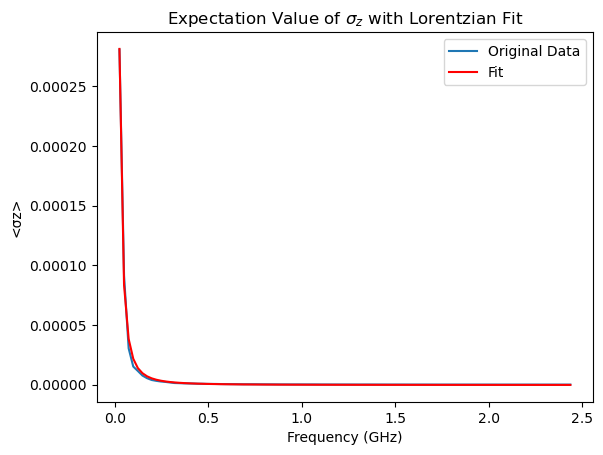

Fitted gamma: 1.28e-02
Fitted 1/gamma: 7.83e+01
Fitted gamma*2pi: 8.02e-02
Fitted 1/gamma/2pi: 1.25e+01
Fitted Offset: -2.73e-07
Fitted Amplitude : 1.33e-03
var of increments (volatility): 3.8568742785135164e-07


In [72]:
lorenztian_fit(t, avgz, T2)

In [69]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:06<00:00, 66.23s/it]


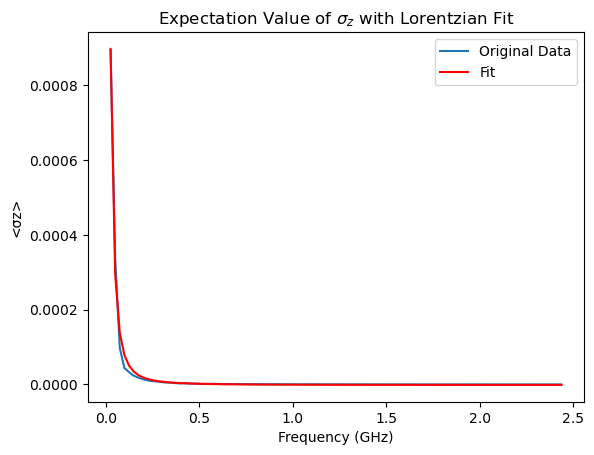

Fitted gamma: 1.69e-02
Fitted 1/gamma: 5.92e+01
Fitted gamma*2pi: 1.06e-01
Fitted 1/gamma/2pi: 9.42e+00
Fitted Offset: -1.34e-06
Fitted Amplitude : 2.81e-03
var of increments (volatility): 1.2161703106864147e-06


In [70]:
lorenztian_fit(t, avgz, T2)

In [75]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.032*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:05<00:00, 65.67s/it]


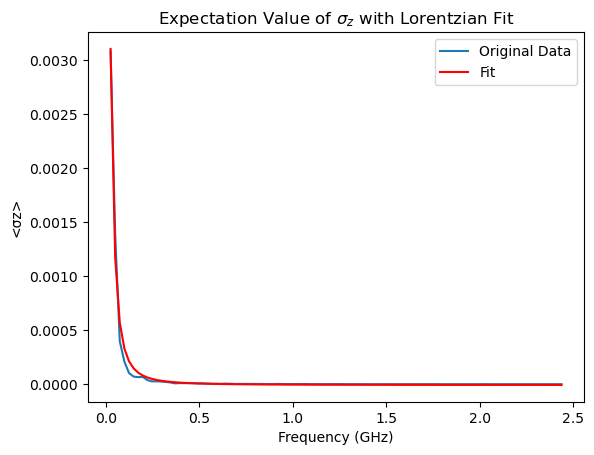

Fitted gamma: 2.24e-02
Fitted 1/gamma: 4.47e+01
Fitted gamma*2pi: 1.40e-01
Fitted 1/gamma/2pi: 7.12e+00
Fitted Offset: -6.88e-06
Fitted Amplitude : 6.89e-03
var of increments (volatility): 4.2134175676265105e-06


In [76]:
lorenztian_fit(t, avgz, T2,)

In [ ]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:13<00:00, 13.79s/it]


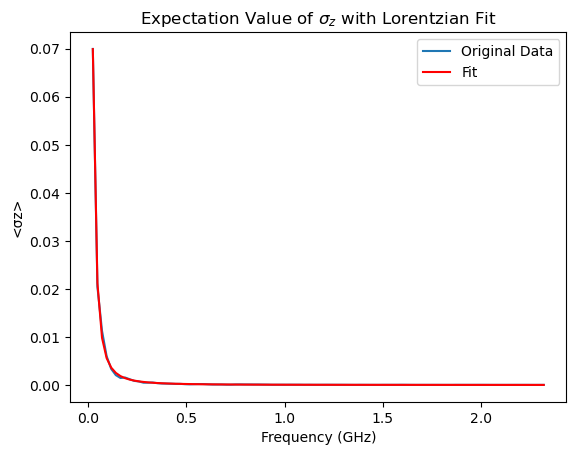

Fitted gamma: -1.29e-02
Fitted 1/gamma: -7.73e+01
Fitted gamma*2pi: -8.13e-02
Fitted 1/gamma/2pi: -1.23e+01
Fitted Offset: -7.78e-06
Fitted Amplitude : 2.99e-01
var of increments (volatility): 0.00011850512911815206


In [ ]:
lorenztian_fit(t, avgz, T2)

In [ ]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:12<00:00, 12.49s/it]


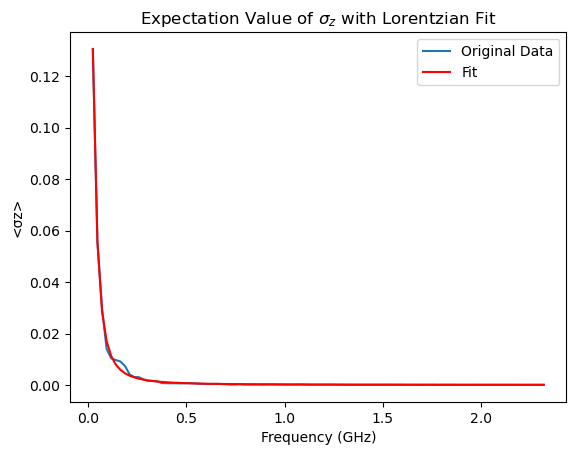

Fitted gamma: 2.61e-02
Fitted 1/gamma: 3.83e+01
Fitted gamma*2pi: 1.64e-01
Fitted 1/gamma/2pi: 6.09e+00
Fitted Offset: 5.36e-05
Fitted Amplitude : 2.35e-01
var of increments (volatility): 0.00038956346327622397


In [ ]:
lorenztian_fit(t, avgz, T2)

In [ ]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.256*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:12<00:00, 12.19s/it]


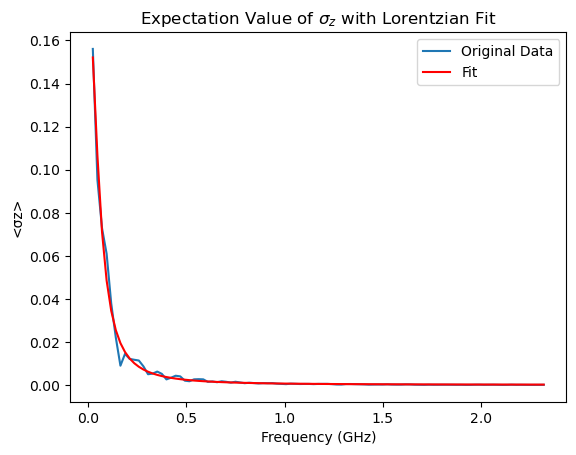

Fitted gamma: -5.75e-02
Fitted 1/gamma: -1.74e+01
Fitted gamma*2pi: -3.61e-01
Fitted 1/gamma/2pi: -2.77e+00
Fitted Offset: 1.43e-04
Fitted Amplitude : 1.77e-01
var of increments (volatility): 0.0017284964175867772


In [ ]:
lorenztian_fit(t, avgz, T2)

## Start of regime change

In [ ]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.512*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:11<00:00, 11.67s/it]


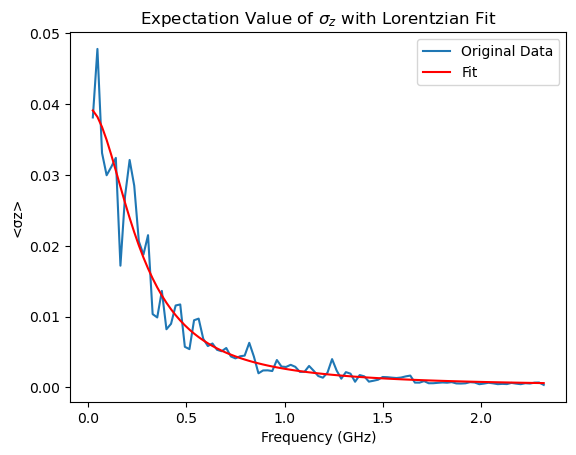

Fitted gamma: 2.62e-01
Fitted 1/gamma: 3.82e+00
Fitted gamma*2pi: 1.64e+00
Fitted 1/gamma/2pi: 6.08e-01
Fitted Offset: 1.26e-04
Fitted Amplitude : 3.93e-02
var of increments (volatility): 0.006462900523835232


In [ ]:
lorenztian_fit(t, avgz, T2/2)

In [ ]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.8*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:13<00:00, 13.32s/it]


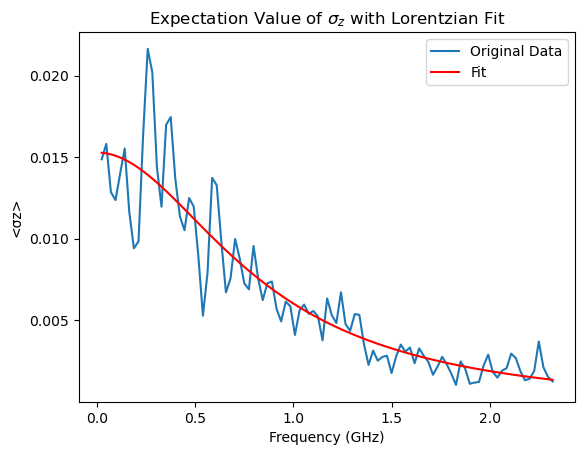

Fitted gamma: -8.37e-01
Fitted 1/gamma: -1.19e+00
Fitted gamma*2pi: -5.26e+00
Fitted 1/gamma/2pi: -1.90e-01
Fitted Offset: -4.67e-04
Fitted Amplitude : 1.58e-02
var of increments (volatility): 0.014716601941160362


In [ ]:
lorenztian_fit(t, avgz, T2)

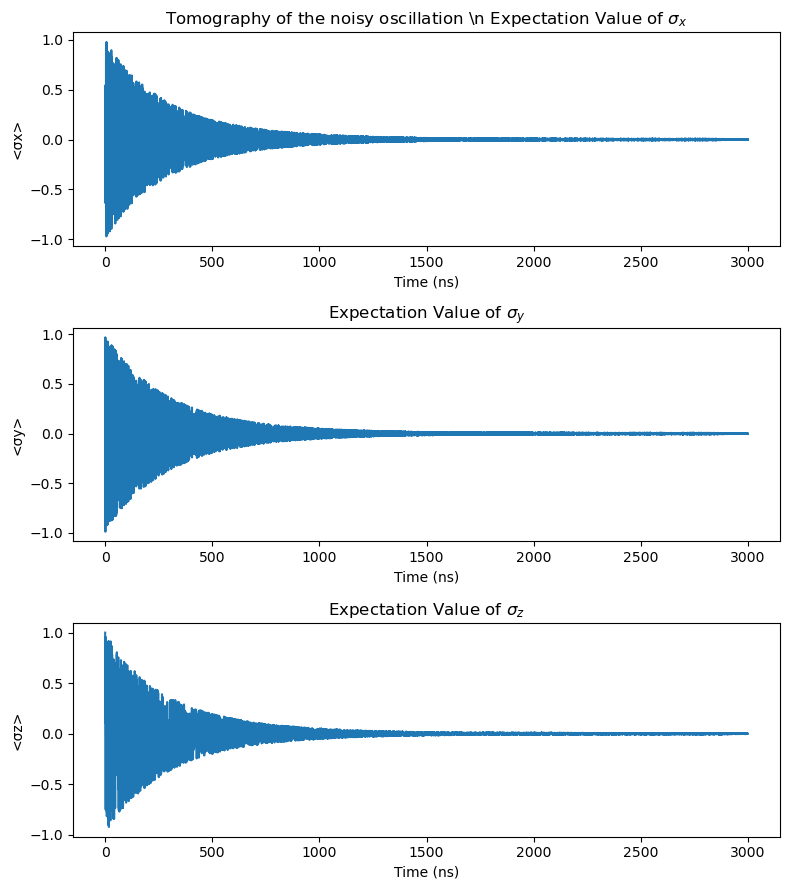

In [ ]:
plot_tomography(t, res.expect)

## Final data analysis

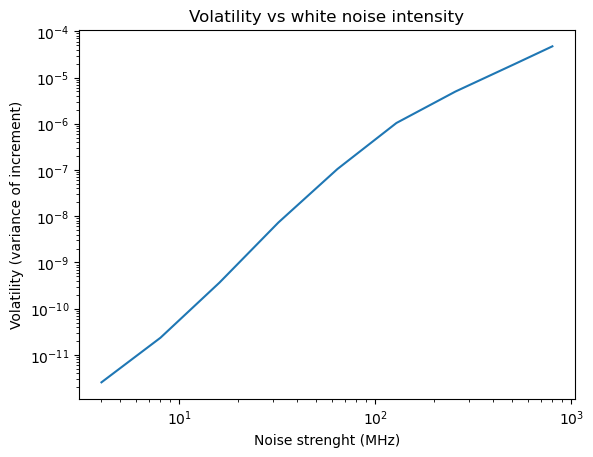

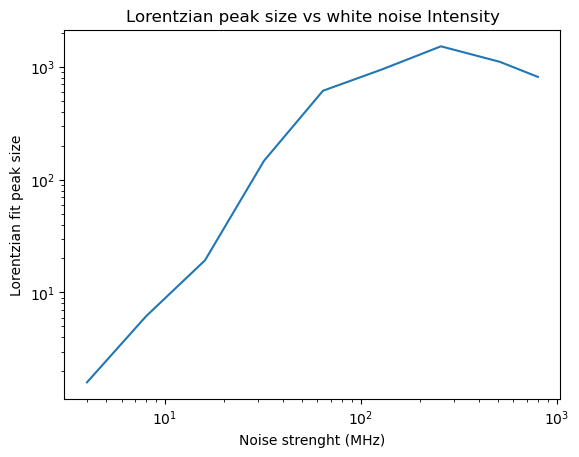

In [9]:
Ed=np.array([0.004,0.008,0.016,0.032,0.064,0.128,0.256,0.512,0.8])
vol=[2.55E-12,2.35E-11,3.66E-10,7.33E-09,1.05E-07,1.04E-06,4.98E-06,1.95E-05,4.74E-05,]
amp=[1.6,6.15,19.27,146.58,612.25,945.99,1515.48,1103.67,811.91,]
plt.loglog(Ed*1000,vol)
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Volatility (variance of increment)")
plt.title("Volatility vs white noise intensity")

plt.show()
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Lorentzian fit peak size")
plt.title("Lorentzian peak size vs white noise Intensity")

plt.loglog(Ed*1000,amp)
plt.show()

# Scan T1 Ed=8MHz T2=200ns
Scans several simulations with different `T1`s with the tile parameters fixed

In [99]:
T1=100 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:10<00:00, 70.49s/it]


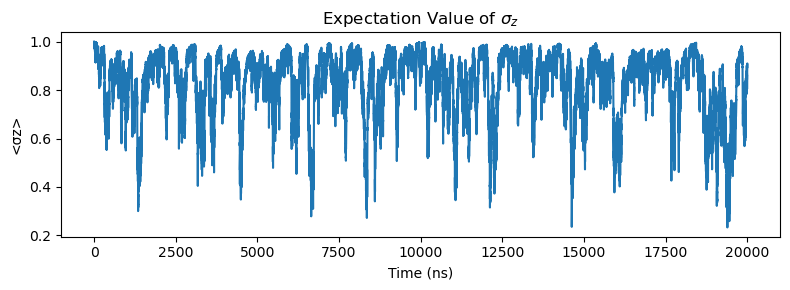

In [100]:
plot_tomography(t, [avgz], graphs="z")

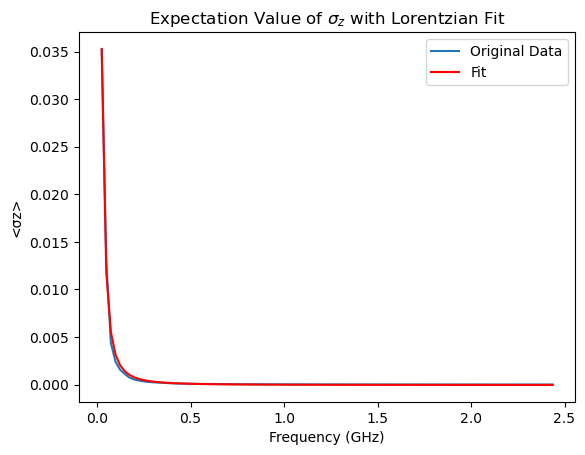

Fitted gamma: 1.74e-02
Fitted 1/gamma: 5.76e+01
Fitted gamma*2pi: 1.09e-01
Fitted 1/gamma/2pi: 9.17e+00
Fitted Offset: -4.57e-05
Fitted Amplitude : 1.06e-01
var of increments (volatility): 4.4707941854016285e-05


In [101]:
lorenztian_fit(t, avgz, T2)

In [102]:
T1=200 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:44<00:00, 44.85s/it]


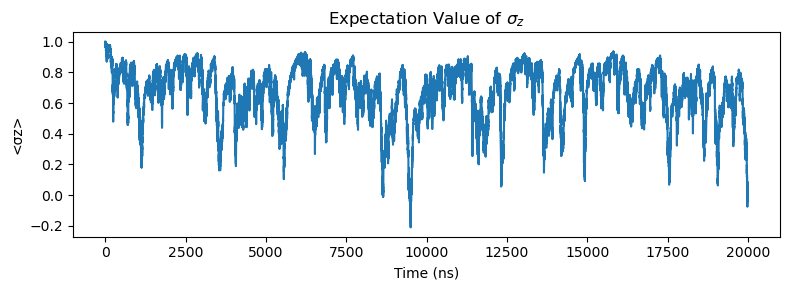

In [103]:
plot_tomography(t, [avgz], graphs="z")

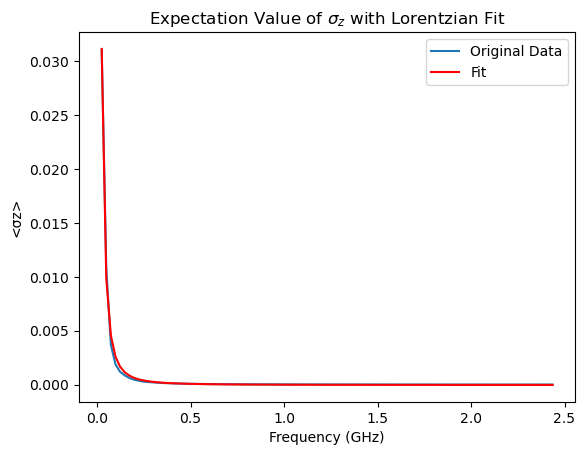

Fitted gamma: 1.51e-02
Fitted 1/gamma: 6.60e+01
Fitted gamma*2pi: 9.51e-02
Fitted 1/gamma/2pi: 1.05e+01
Fitted Offset: -3.75e-05
Fitted Amplitude : 1.14e-01
var of increments (volatility): 3.797166646843633e-05


In [104]:
lorenztian_fit(t, avgz, T2)

In [105]:
T1=500 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:17<00:00, 17.01s/it]


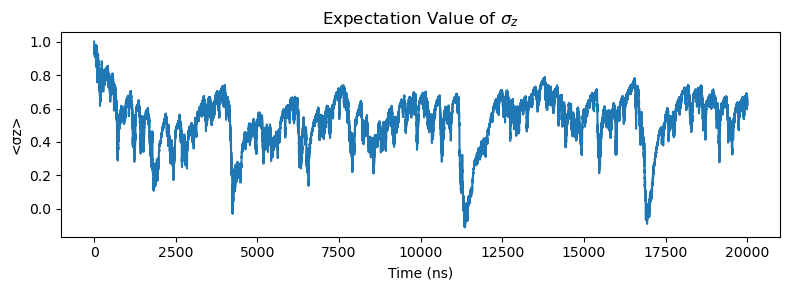

In [106]:
plot_tomography(t, [avgz], graphs="z")

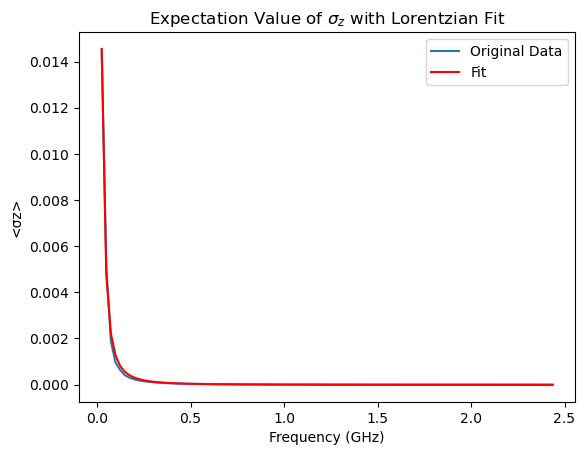

Fitted gamma: 1.65e-02
Fitted 1/gamma: 6.07e+01
Fitted gamma*2pi: 1.04e-01
Fitted 1/gamma/2pi: 9.66e+00
Fitted Offset: -1.68e-05
Fitted Amplitude : 4.71e-02
var of increments (volatility): 1.858123306521588e-05


In [107]:
lorenztian_fit(t, avgz, T2)

In [108]:
T1=1000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:17<00:00, 17.15s/it]


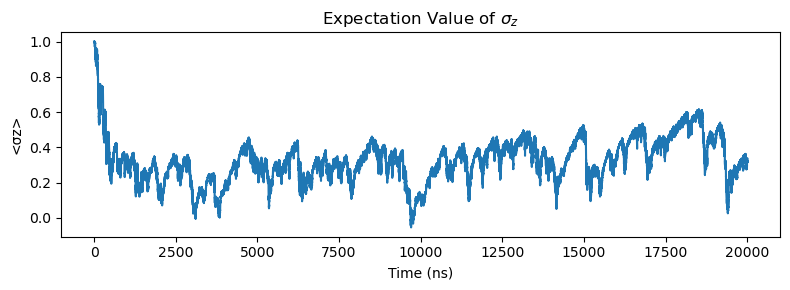

In [109]:
plot_tomography(t, [avgz], graphs="z")

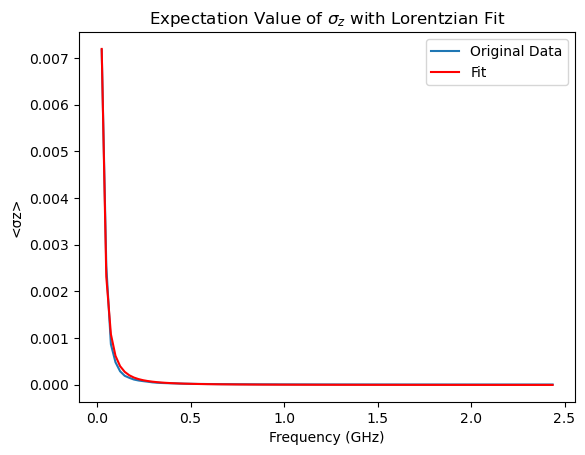

Fitted gamma: 1.60e-02
Fitted 1/gamma: 6.25e+01
Fitted gamma*2pi: 1.00e-01
Fitted 1/gamma/2pi: 9.95e+00
Fitted Offset: -8.86e-06
Fitted Amplitude : 2.43e-02
var of increments (volatility): 9.033526693598699e-06


In [110]:
lorenztian_fit(t, avgz, T2)

## Start of regime change

In [111]:
T1=2000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:16<00:00, 16.97s/it]


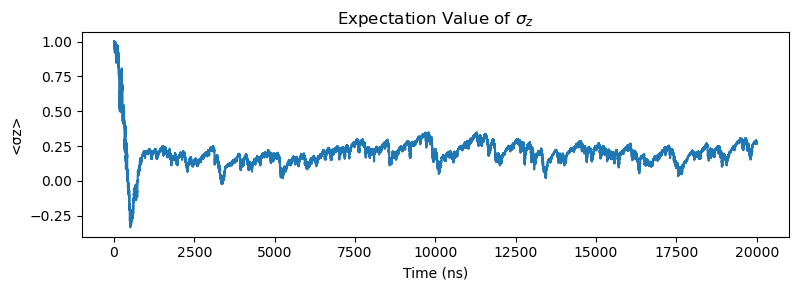

In [112]:
plot_tomography(t, [avgz], graphs="z")

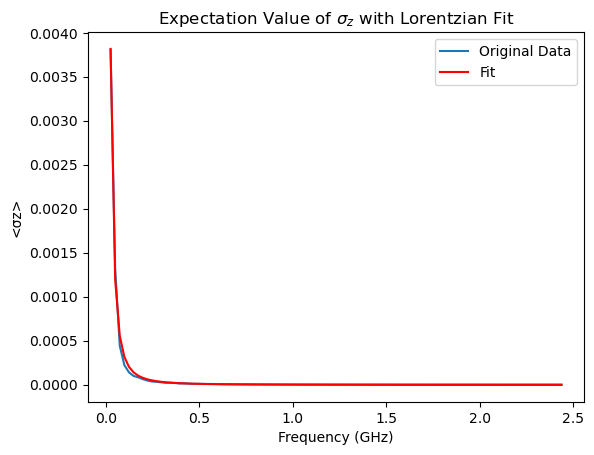

Fitted gamma: 1.49e-02
Fitted 1/gamma: 6.71e+01
Fitted gamma*2pi: 9.36e-02
Fitted 1/gamma/2pi: 1.07e+01
Fitted Offset: -4.63e-06
Fitted Amplitude : 1.43e-02
var of increments (volatility): 4.447795073354453e-06


In [113]:
lorenztian_fit(t, avgz, T2)

In [114]:
T1=3000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:17<00:00, 17.33s/it]


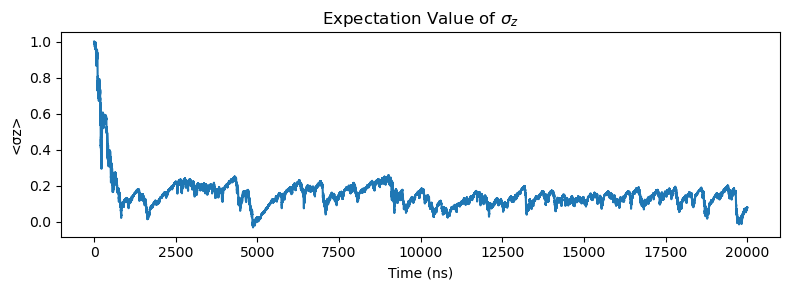

In [115]:
plot_tomography(t, [avgz], graphs="z")

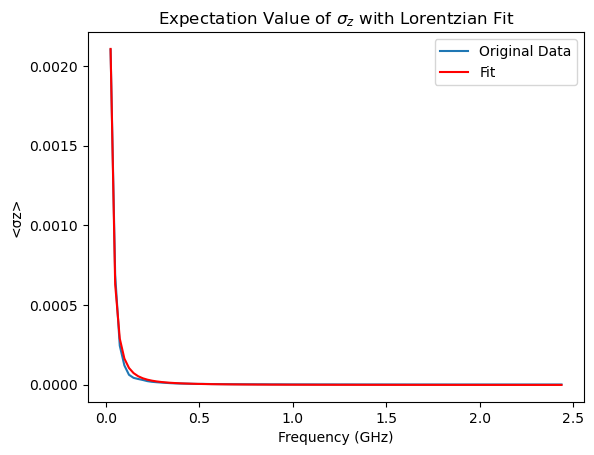

Fitted gamma: 1.30e-02
Fitted 1/gamma: 7.68e+01
Fitted gamma*2pi: 8.18e-02
Fitted 1/gamma/2pi: 1.22e+01
Fitted Offset: -2.72e-06
Fitted Amplitude : 9.64e-03
var of increments (volatility): 2.1997891391765147e-06


In [116]:
lorenztian_fit(t, avgz, T2)

In [117]:
T1=5000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [00:15<00:00, 15.95s/it]


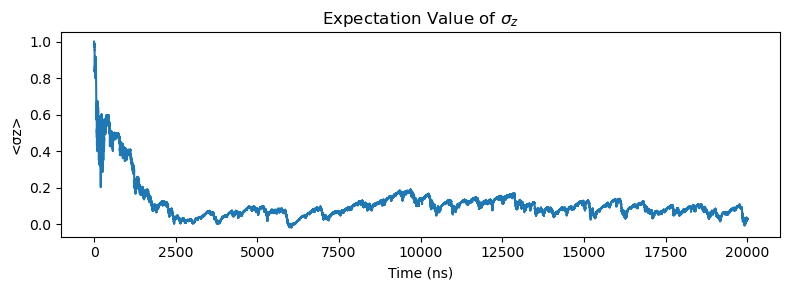

In [118]:
plot_tomography(t, [avgz], graphs="z")

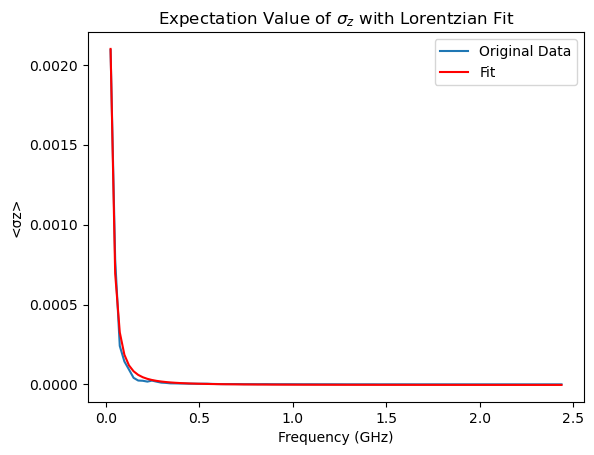

Fitted gamma: 1.72e-02
Fitted 1/gamma: 5.83e+01
Fitted gamma*2pi: 1.08e-01
Fitted 1/gamma/2pi: 9.28e+00
Fitted Offset: -3.67e-06
Fitted Amplitude : 6.43e-03
var of increments (volatility): 2.140972612695609e-06


In [119]:
lorenztian_fit(t, avgz, T2)

# Scan T2 Ed=8MHz T1=10000ns
Scans several simulations with different `T2`s with the tile parameters fixed

In [124]:
T1=10000 #relaxation time [ns]
T2=500 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:21<00:00, 81.44s/it]


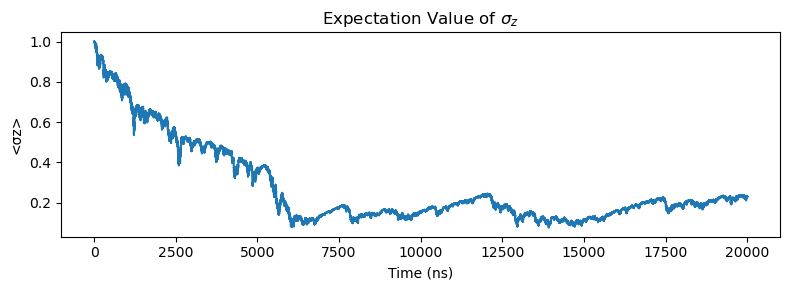

In [125]:
plot_tomography(t, [avgz], graphs="z")

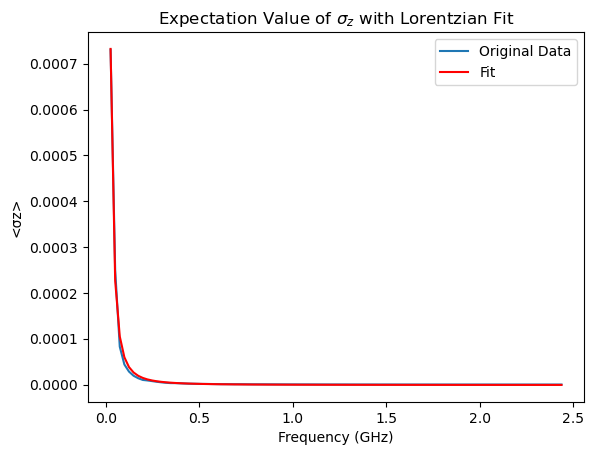

Fitted gamma: 1.45e-02
Fitted 1/gamma: 6.88e+01
Fitted gamma*2pi: 9.13e-02
Fitted 1/gamma/2pi: 1.09e+01
Fitted Offset: -8.54e-07
Fitted Amplitude : 2.83e-03
var of increments (volatility): 8.724660365675875e-07


In [126]:
lorenztian_fit(t, avgz, T2)

In [127]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:18<00:00, 78.58s/it]


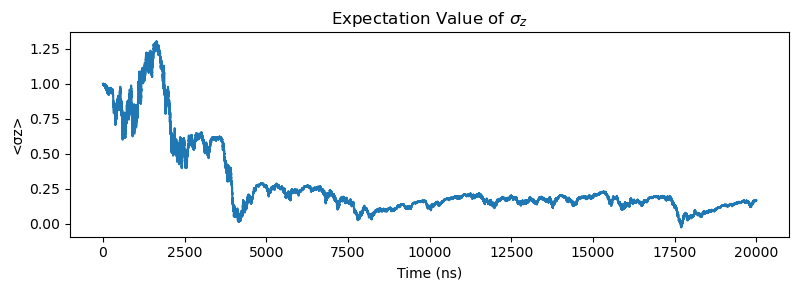

In [128]:
plot_tomography(t, [avgz], graphs="z")

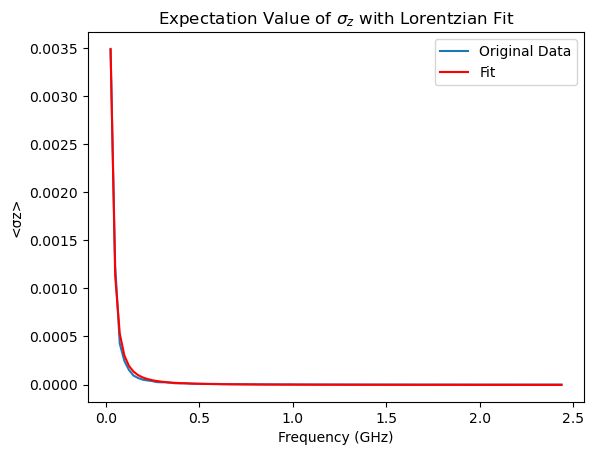

Fitted gamma: 1.63e-02
Fitted 1/gamma: 6.12e+01
Fitted gamma*2pi: 1.03e-01
Fitted 1/gamma/2pi: 9.74e+00
Fitted Offset: -4.09e-06
Fitted Amplitude : 1.14e-02
var of increments (volatility): 4.567747727739246e-06


In [129]:
lorenztian_fit(t, avgz, T2)

In [130]:
T1=10000 #relaxation time [ns]
T2=2000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:11<00:00, 71.70s/it]


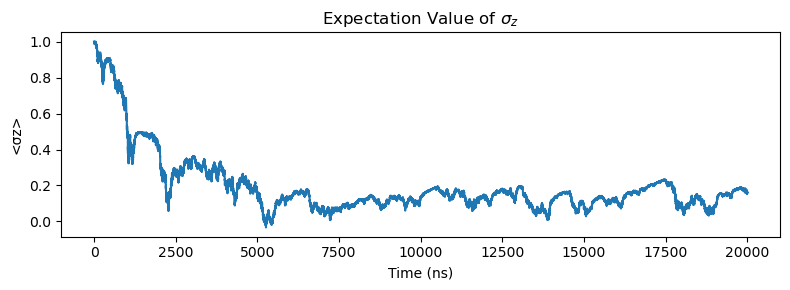

In [131]:
plot_tomography(t, [avgz], graphs="z")

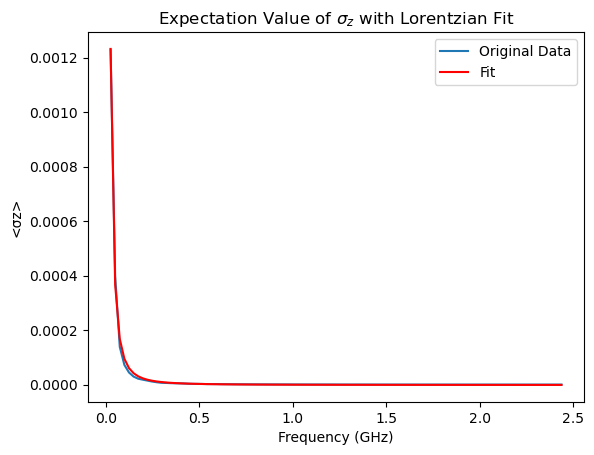

Fitted gamma: 1.28e-02
Fitted 1/gamma: 7.83e+01
Fitted gamma*2pi: 8.02e-02
Fitted 1/gamma/2pi: 1.25e+01
Fitted Offset: -1.32e-06
Fitted Amplitude : 5.82e-03
var of increments (volatility): 1.390801098213451e-06


In [132]:
lorenztian_fit(t, avgz, T2)

In [133]:
T1=10000 #relaxation time [ns]
T2=4000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:11<00:00, 71.94s/it]


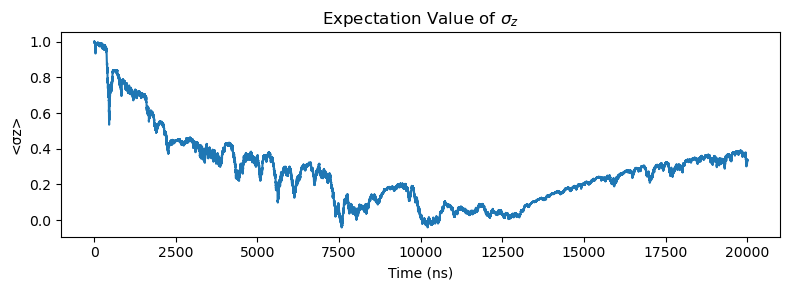

In [134]:
plot_tomography(t, [avgz], graphs="z")

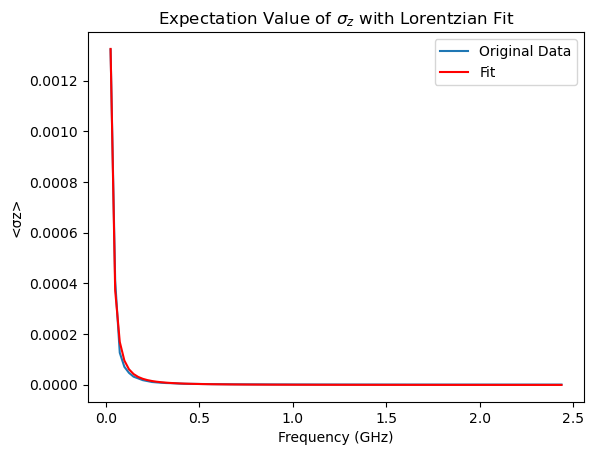

Fitted gamma: 1.03e-02
Fitted 1/gamma: 9.73e+01
Fitted gamma*2pi: 6.46e-02
Fitted 1/gamma/2pi: 1.55e+01
Fitted Offset: -1.35e-06
Fitted Amplitude : 8.93e-03
var of increments (volatility): 1.4176037473719848e-06


In [135]:
lorenztian_fit(t, avgz, T2)

In [136]:
T1=10000 #relaxation time [ns]
T2=10000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [01:11<00:00, 71.77s/it]


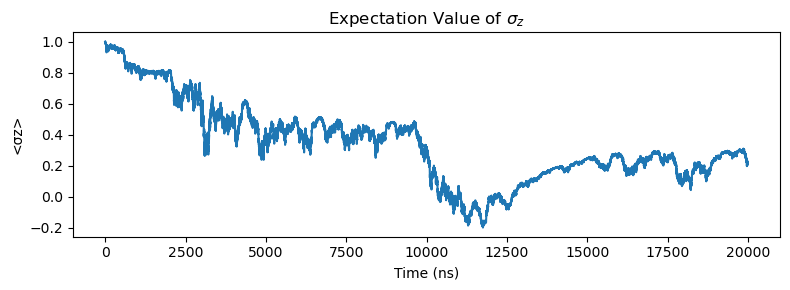

In [137]:
plot_tomography(t, [avgz], graphs="z")

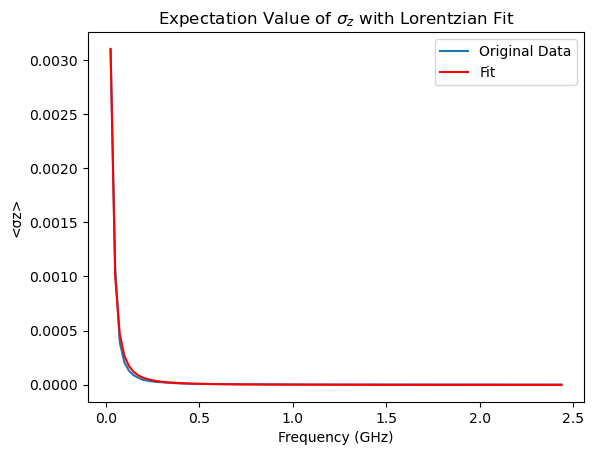

Fitted gamma: 1.61e-02
Fitted 1/gamma: 6.23e+01
Fitted gamma*2pi: 1.01e-01
Fitted 1/gamma/2pi: 9.91e+00
Fitted Offset: -3.78e-06
Fitted Amplitude : 1.04e-02
var of increments (volatility): 3.7424431149709486e-06


In [138]:
lorenztian_fit(t, avgz, T2)

In [6]:
T1=10000 #relaxation time [ns]
T2=20000 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

100%|██████████| 1/1 [01:11<00:00, 71.31s/it]


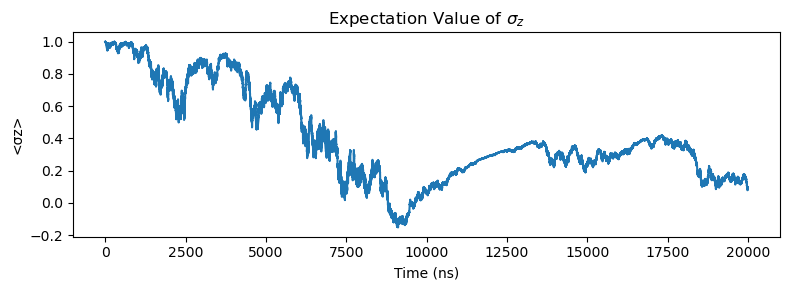

In [6]:
plot_tomography(t, [avgz], graphs="z")

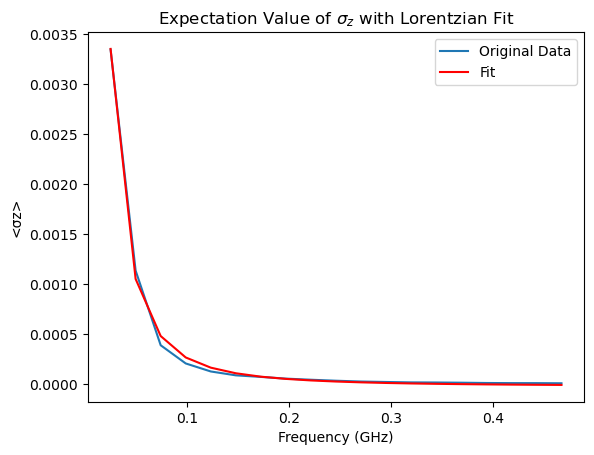

Fitted gamma: 1.55e-02
Fitted 1/gamma: 6.44e+01
Fitted gamma*2pi: 9.76e-02
Fitted 1/gamma/2pi: 1.02e+01
Fitted Offset: -2.14e-05
Fitted Amplitude : 1.18e-02
var of increments (volatility): 5.454658364307928e-06


In [7]:
lorenztian_fit(t, res.expect[2], T2, split=20)